In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip -q "/content/drive/MyDrive/datasets/Timor_dataset.zip" -d "/content/drive/MyDrive/datasets/Timor_dataset_unzipped"


replace /content/drive/MyDrive/datasets/Timor_dataset_unzipped/Testing/glioma/Te-glTr_0000.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
import zipfile, os

zip_path = "/content/drive/MyDrive/datasets/Timor_dataset.zip"
extract_path = "/content/brain_tumor_data"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted to:", os.listdir(extract_path))


Extracted to: ['Training', 'Testing']


In [ ]:
import os

print("Extracted path:", extract_path)
print("Subfolders:", os.listdir(extract_path))


Extracted path: /content/brain_tumor_data
Subfolders: ['Training', 'Testing']


In [ ]:
import os

# Define dataset directory
data_dir = "/content/drive/MyDrive/datasets/Timor_dataset_unzipped"

# Handle cases where extracted files are nested inside another folder
possible_subdirs = os.listdir(data_dir)
print("Possible subfolders:", possible_subdirs)

# Try to find 'Training' and 'Testing' folders
if "Training" in possible_subdirs and "Testing" in possible_subdirs:
    train_path = os.path.join(data_dir, "Training")
    val_path   = os.path.join(data_dir, "Testing")
else:
    for sub in possible_subdirs:
        sub_path = os.path.join(data_dir, sub)
        if os.path.isdir(sub_path):
            if "Training" in os.listdir(sub_path):
                train_path = os.path.join(sub_path, "Training")
                val_path = os.path.join(sub_path, "Testing")
                break

print("Training path:", train_path)
print("Validation path:", val_path)


Possible subfolders: ['Testing', 'Training']
Training path: /content/drive/MyDrive/datasets/Timor_dataset_unzipped/Training
Validation path: /content/drive/MyDrive/datasets/Timor_dataset_unzipped/Testing


In [ ]:
import tensorflow as tf  # ✅ Fixes the NameError

# Normalize and prefetch
normalizer = tf.keras.layers.Rescaling(1./255)
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(lambda x, y: (normalizer(x), y)).cache().prefetch(AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (normalizer(x), y)).cache().prefetch(AUTOTUNE)


In [ ]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

IMG_SIZE = (224, 224)
BATCH = 32

train_ds = image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH,
    shuffle=True
)

val_ds = image_dataset_from_directory(
    val_path,
    image_size=IMG_SIZE,
    batch_size=BATCH,
    shuffle=False
)

# Extract class names
class_names = train_ds.class_names
n_classes = len(class_names)
print("Classes:", class_names)

# Normalize and prefetch
normalizer = tf.keras.layers.Rescaling(1./255)
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(lambda x, y: (normalizer(x), y)).cache().prefetch(AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (normalizer(x), y)).cache().prefetch(AUTOTUNE)


Found 5712 files belonging to 4 classes.
Found 1311 files belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
import os

# Define dataset paths (adjust if necessary)
data_dir = "/content/drive/MyDrive/datasets/Timor_dataset_unzipped"  # Update based on your unzip location

train_path = os.path.join(data_dir, "Training")
val_path = os.path.join(data_dir, "Testing")

IMG_SIZE = (224, 224)
BATCH = 32

# Load datasets
train_ds = image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH,
    shuffle=True
)

val_ds = image_dataset_from_directory(
    val_path,
    image_size=IMG_SIZE,
    batch_size=BATCH,
    shuffle=False
)


Found 5712 files belonging to 4 classes.
Found 1311 files belonging to 4 classes.


In [ ]:
class_names = train_ds.class_names
n_classes = len(class_names)
print("Classes:", class_names)


Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, models, optimizers

base_model = DenseNet121(weights="imagenet", include_top=False, input_shape=(224,224,3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(n_classes, activation='softmax')
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 992s 5s/step - accuracy: 0.4394 - loss: 1.8804 - val_accuracy: 0.7353 - val_loss: 0.8029
Epoch 2/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 25s 142ms/step - accuracy: 0.7193 - loss: 0.7506 - val_accuracy: 0.7773 - val_loss: 0.6364
Epoch 3/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 25s 141ms/step - accuracy: 0.7878 - loss: 0.5650 - val_accuracy: 0.8070 - val_loss: 0.5628
Epoch 4/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 24s 134ms/step - accuracy: 0.8178 - loss: 0.4956 - val_accuracy: 0.8101 - val_loss: 0.5434
Epoch 5/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 43s 144ms/step - accuracy: 0.8284 - loss: 0.4630 - val_accuracy: 0.8276 - val_loss: 0.4994
Epoch 6/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 27s 150ms/step - accuracy: 0.8603 - loss: 0.4215 - val_accuracy: 0.8406 - val_loss: 0.4574
Epoch 7/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 27s 150ms/step - accuracy: 0.8575 - loss: 0.4010 - val_accuracy: 0.8490 - val_loss: 0.4329
Epoch 8/20
179/179 ━━━━━━━━━━━━━━━

In [ ]:
weights_path = "/content/drive/MyDrive/datasets/DenseNet121_Timor_20epochs.weights.h5"
model.save_weights(weights_path)
print(f"Weights saved at: {weights_path}")


Weights saved at: /content/drive/MyDrive/datasets/DenseNet121_Timor_20epochs.weights.h5


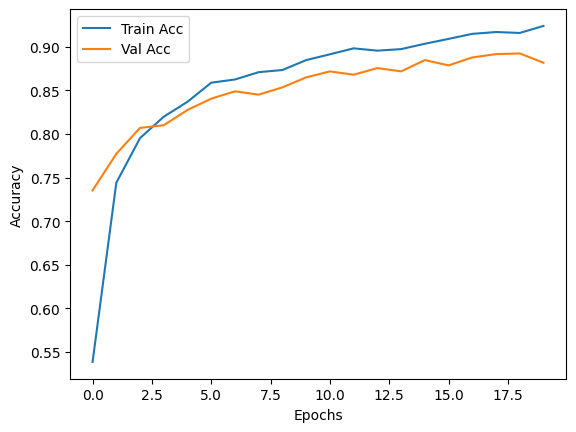

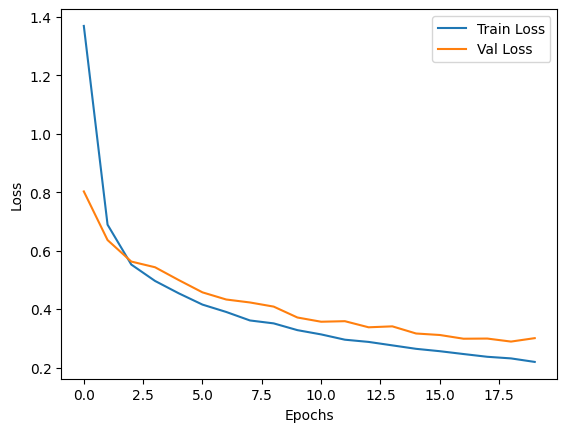

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()
